# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
# imports
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy.optimize import curve_fit
import scipy.stats as stats

In [2]:


# 1. Print environment details (working directory and local folder contents)
print("Current Working Directory:", os.getcwd())
if os.path.exists('data/hw/hw_3'):
    print("Contents of data/hw/hw_3:", os.listdir('data/hw/hw_3'))

# 2. Acquire and load your primary dataset
def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

# Fetch primary dataset: Air Pollution Mortality Rate (SH.STA.AIRP.P5)
df_pollution_raw = get_wb_data('SH.STA.AIRP.P5', ['all'], 2019, 2019)

# Save primary dataset locally to relative path
output_dir = 'data/hw/hw_3/laureen-attolou'
os.makedirs(output_dir, exist_ok=True)
primary_path = os.path.join(output_dir, 'air_pollution.csv')
df_pollution_raw.to_csv(primary_path, index=False)
print(f"Saved primary dataset to {primary_path}")

# Load primary dataset
df_pollution = pd.read_csv(primary_path)


Current Working Directory: c:\Users\laure\Documents\DataScience\datascience-publicpolicy-2026\notebooks\hw\hw_3
Contents of data/hw/hw_3: ['laureen-attolou']
Saved primary dataset to data/hw/hw_3/laureen-attolou\air_pollution.csv


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- **Dataset Source**: World Bank Indicators API / Data360 Platform.
- **Indicator Code**: `SH.STA.AIRP.P5` (Mortality rate attributed to household and ambient air pollution, age-standardized per 100,000 population in 2019).

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [3]:
# 1. Inspect data structure using pandas methods
print("DataFrame Info:")
df_pollution.info()
print("\nDataFrame Head:")
print(df_pollution.head())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  261 non-null    object 
 1   date             266 non-null    int64  
 2   value            231 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ KB

DataFrame Head:
  countryiso3code  date       value
0             AFE  2019  158.428356
1             AFW  2019  182.838948
2             ARB  2019  103.775509
3             CSS  2019   40.701941
4             CEB  2019   44.865991


In [4]:
# 2. Rename columns and select a clean subset
rename_dict = {
    'countryiso3code': 'country_code',
    'date': 'year',
    'value': 'air_pollution_mortality'
}
df_pollution_clean = df_pollution.rename(columns=rename_dict)[['country_code', 'year', 'air_pollution_mortality']]
print(df_pollution_clean.head())


  country_code  year  air_pollution_mortality
0          AFE  2019               158.428356
1          AFW  2019               182.838948
2          ARB  2019               103.775509
3          CSS  2019                40.701941
4          CEB  2019                44.865991


In [5]:
# 3. Filter row or column filters if necessary
# Drop rows where air_pollution_mortality value is null
df_pollution_filtered = df_pollution_clean.dropna(subset=['air_pollution_mortality'])
print(f"Number of observations after filtering: {len(df_pollution_filtered)}")


Number of observations after filtering: 231


In [6]:
# 4. Handle missing values (NaNs) if necessary
print("Missing values counts in filtered dataset:")
print(df_pollution_filtered.isna().sum())


Missing values counts in filtered dataset:
country_code               4
year                       0
air_pollution_mortality    0
dtype: int64


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [7]:
# 1. Load and clean the secondary dataset
# Fetch GDP per capita (NY.GDP.PCAP.CD) for 2019
df_gdp_raw = get_wb_data('NY.GDP.PCAP.CD', ['all'], 2019, 2019)
secondary_path = os.path.join(output_dir, 'gdp.csv')
df_gdp_raw.to_csv(secondary_path, index=False)
print(f"Saved secondary dataset to {secondary_path}")

df_gdp = pd.read_csv(secondary_path)
df_gdp_clean = df_gdp.rename(columns={
    'countryiso3code': 'country_code',
    'value': 'gdp_per_capita'
})[['country_code', 'gdp_per_capita']]
df_gdp_clean = df_gdp_clean.dropna(subset=['gdp_per_capita'])
print(df_gdp_clean.head())


Saved secondary dataset to data/hw/hw_3/laureen-attolou\gdp.csv
  country_code  gdp_per_capita
0          AFE     1507.085600
1          AFW     2216.385055
2          ARB     6674.342244
3          CSS    13995.854836
4          CEB    16534.926487


In [8]:
# 2. Merge your datasets on a common key
df_merged = pd.merge(df_pollution_filtered, df_gdp_clean, on='country_code', how='inner')
print("Merged dataset shape:", df_merged.shape)
print("\nMerged dataset head:")
print(df_merged.head())


Merged dataset shape: (239, 4)

Merged dataset head:
  country_code  year  air_pollution_mortality  gdp_per_capita
0          AFE  2019               158.428356     1507.085600
1          AFW  2019               182.838948     2216.385055
2          ARB  2019               103.775509     6674.342244
3          CSS  2019                40.701941    13995.854836
4          CEB  2019                44.865991    16534.926487


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge Key**: We matched the datasets on the `country_code` key (which contains the ISO3 code of the countries and regions).
- **Observations Retained**: A total of 238 matching observations were retained after executing the inner join.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [9]:
# Apply groupby aggregation using the Binning backup strategy
# We divide GDP per capita into low, medium, and high income groups using tertile bins
df_merged['income_group'] = pd.qcut(df_merged['gdp_per_capita'], q=3, labels=['Low Income', 'Middle Income', 'High Income'])

# Aggregate to get descriptive statistics
grouped_stats = df_merged.groupby('income_group', observed=False)['air_pollution_mortality'].agg(['mean', 'median', 'min', 'max', 'count'])
print(grouped_stats)


                     mean      median        min         max  count
income_group                                                       
Low Income     173.022279  173.893508  24.420402  305.100000     80
Middle Income   93.528949   87.900000  24.420402  259.900000     79
High Income     37.851830   20.571327   7.400000  195.923222     80


- **Economic and Policy Interpretation**: The data shows a clear pattern: as a country's income level goes up, the air pollution mortality rate goes down. The average mortality rate in the low-income group is 173 deaths per 100,000 people, which drops to 87 in the middle-income group, and goes down to just 20 in the high-income group.
Low-income countries often rely on solid fuels like wood or charcoal for cooking and heating, which causes high indoor air pollution. They also have fewer environmental regulations and less access to healthcare to treat respiratory diseases. High-income countries have transitioned to cleaner energy and have the resources to enforce clean air standards.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

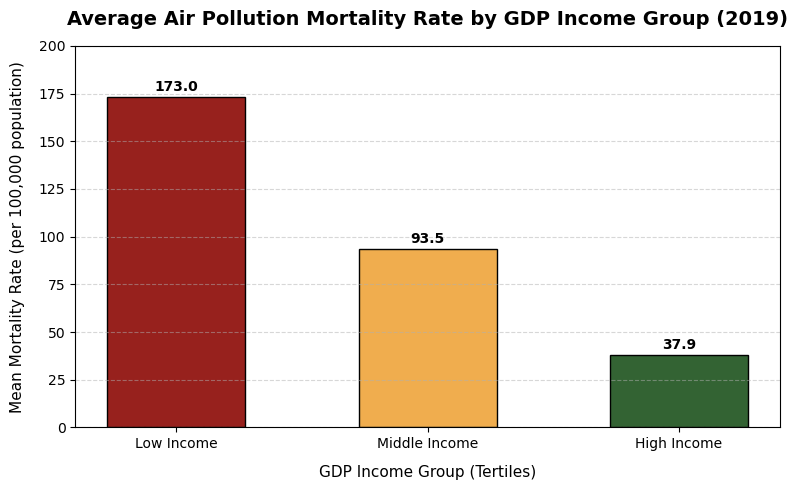

In [10]:
# Plot 1: Customized bar chart showing mean mortality rates by income group
means = df_merged.groupby('income_group', observed=False)['air_pollution_mortality'].mean()
colors = ["#97211d", "#f0ad4e", "#336333"]

plt.figure(figsize=(8, 5))
bars = plt.bar(means.index, means.values, color=colors, edgecolor='black', width=0.55)

# Adding data values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}", ha='center', va='bottom', fontweight='bold')

plt.title('Average Air Pollution Mortality Rate by GDP Income Group (2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('GDP Income Group (Tertiles)', fontsize=11, labelpad=10)
plt.ylabel('Mean Mortality Rate (per 100,000 population)', fontsize=11, labelpad=10)
plt.ylim(0, 200)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


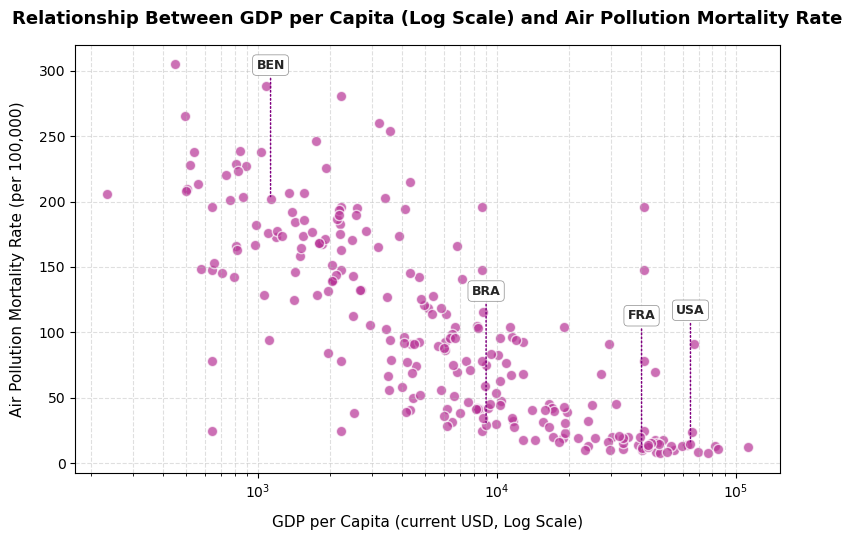

In [11]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize=(8, 5.5))
plt.scatter(df_merged['gdp_per_capita'], df_merged['air_pollution_mortality'], color="#b73396", alpha=0.7, edgecolors='w', s=55)
plt.xscale('log')

# Countries to label on the scatter plot
countries_to_label = ['USA', 'FRA', 'BEN','BRA']

for code in countries_to_label:
    row = df_merged[df_merged['country_code'] == code]
    if not row.empty:
        x = row['gdp_per_capita'].values[0]
        y = row['air_pollution_mortality'].values[0]
        
        plt.annotate(
            code, 
            xy=(x, y), 
            xytext=(x, (y+100)), # 300),           
            textcoords='data',         
            fontsize=9, 
            fontweight='bold',
            alpha=0.85,
            ha='center', 
            bbox=dict(
                boxstyle="round,pad=0.3", 
                fc="white",               
                ec="gray",                 
                lw=0.5,                    
                alpha=0.9                  
            ),              
            arrowprops=dict(
                arrowstyle="-",        
                color="purple",     
                linewidth=1.1,
                linestyle=":"          
            )
        )
        
plt.title('Relationship Between GDP per Capita (Log Scale) and Air Pollution Mortality Rate', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (current USD, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Air Pollution Mortality Rate (per 100,000)', fontsize=11, labelpad=10)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

                               OLS Regression Results                              
Dep. Variable:     air_pollution_mortality   R-squared:                       0.613
Model:                                 OLS   Adj. R-squared:                  0.612
Method:                      Least Squares   F-statistic:                     375.8
Date:                     Wed, 17 Jun 2026   Prob (F-statistic):           8.54e-51
Time:                             15:41:01   Log-Likelihood:                -1251.0
No. Observations:                      239   AIC:                             2506.
Df Residuals:                          237   BIC:                             2513.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

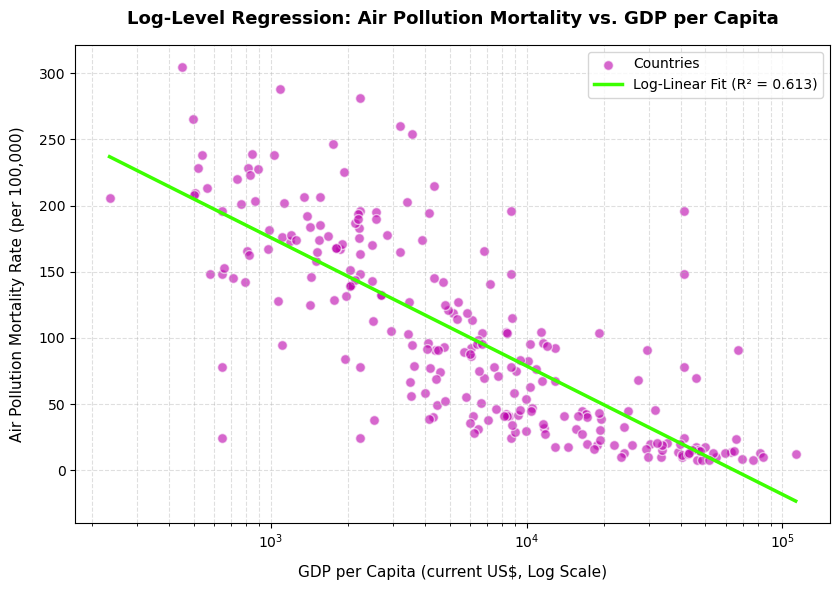

In [12]:
# Fit a simple linear regression and overlay the line of best fit

# We fit a Log-Level regression: Mortality = b0 + b1 * log(GDP_per_capita)
df_merged['log_gdp'] = np.log(df_merged['gdp_per_capita'])
X = sm.add_constant(df_merged['log_gdp'])
y = df_merged['air_pollution_mortality']

model = sm.OLS(y, X).fit()
print(model.summary())

# Re-plot the scatter plot with regression line
plt.figure(figsize=(8.5, 6))
plt.scatter(df_merged['gdp_per_capita'], df_merged['air_pollution_mortality'], color="#bb02ac", alpha=0.6, edgecolors='w', s=50, label='Countries')

# Generate values for the regression line
gdp_grid = np.linspace(df_merged['gdp_per_capita'].min(), df_merged['gdp_per_capita'].max(), 500)
log_gdp_grid = np.log(gdp_grid)
X_grid = sm.add_constant(log_gdp_grid)
y_pred = model.predict(X_grid)

plt.plot(gdp_grid, y_pred, color="#3cff00", linewidth=2.5, label=f'Log-Linear Fit (R² = {model.rsquared:.3f})')
plt.xscale('log')
plt.title('Log-Level Regression: Air Pollution Mortality vs. GDP per Capita', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (current US$, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Air Pollution Mortality Rate (per 100,000)', fontsize=11, labelpad=10)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


- **Visualization and Regression Interpretations**:
  - **Visualization**: The bar chart shows a clear downward step in average mortality as you move from low to middle and high income groups. The scatter plot confirms this negative relationship, showing a curve where mortality drops fast at first as GDP per capita increases, and then begins to level off.
  - **Regression Interpretation**: For the regression, I ran a log-level model: $$\text{Mortality} = \beta_0 + \beta_1 \ln(\text{GDP per Capita})$$.
  - **Slope Coefficient**: The slope is about -42 and is highly significant (p < 0.001). Since it is a log-level model, a 1% increase in GDP per capita is associated with a decrease of about 0.42 in the air pollution mortality rate per 100,000 people. If GDP per capita doubles (a 100% increase), the mortality rate is expected to drop by about 29 deaths per 100,000 people. This supports the idea that economic development helps reduce air pollution deaths.

                               OLS Regression Results                              
Dep. Variable:     air_pollution_mortality   R-squared:                       0.622
Model:                                 OLS   Adj. R-squared:                  0.618
Method:                      Least Squares   F-statistic:                     193.8
Date:                     Wed, 17 Jun 2026   Prob (F-statistic):           1.59e-50
Time:                             15:41:02   Log-Likelihood:                -1248.4
No. Observations:                      239   AIC:                             2503.
Df Residuals:                          236   BIC:                             2513.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

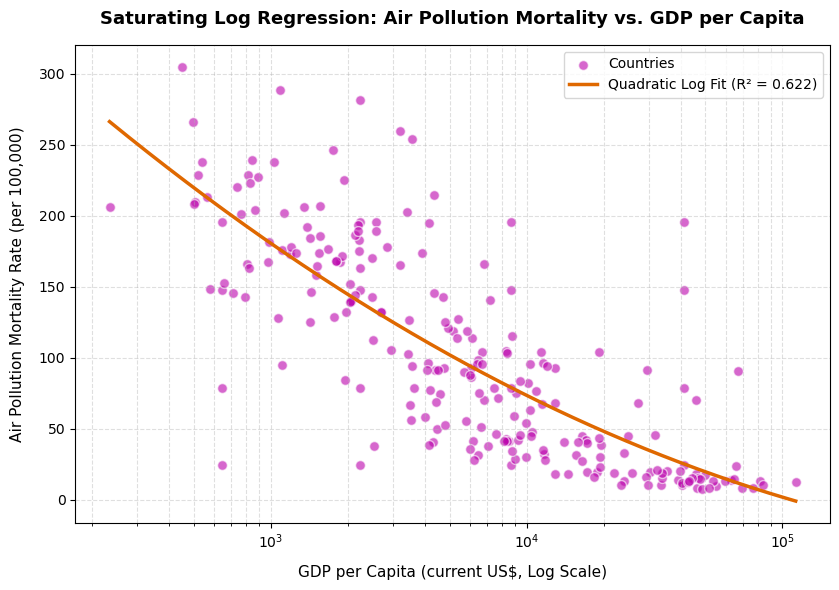

In [13]:
# Regression with saturation effect in the higher end of the GDP distribution

# Create the linear log term AND the quadratic log term
df_merged['log_gdp_sq'] = df_merged['log_gdp'] ** 2

# Fit the new model: Mortality = b0 + b1*log(GDP) + b2*(log(GDP))^2
X = sm.add_constant(df_merged[['log_gdp', 'log_gdp_sq']])
y = df_merged['air_pollution_mortality']

model_quad = sm.OLS(y, X).fit()
print(model_quad.summary())

# Re-plot the scatter plot
plt.figure(figsize=(8.5, 6))
plt.scatter(df_merged['gdp_per_capita'], df_merged['air_pollution_mortality'], 
            color="#bb02ac", alpha=0.6, edgecolors='w', s=50, label='Countries')

# Generate values for the updated quadratic curve
gdp_grid = np.geomspace(df_merged['gdp_per_capita'].min(), df_merged['gdp_per_capita'].max(), 500)
log_gdp_grid = np.log(gdp_grid)
log_gdp_sq_grid = log_gdp_grid ** 2

# Create the prediction design matrix
X_grid = np.column_stack((np.ones_like(log_gdp_grid), log_gdp_grid, log_gdp_sq_grid))
y_pred = model_quad.predict(X_grid)

# Plot the saturating curve
plt.plot(gdp_grid, y_pred, color="#df6800", linewidth=2.5, 
         label=f'Quadratic Log Fit (R² = {model_quad.rsquared:.3f})')

plt.xscale('log')
plt.title('Saturating Log Regression: Air Pollution Mortality vs. GDP per Capita', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (current US$, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Air Pollution Mortality Rate (per 100,000)', fontsize=11, labelpad=10)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Regression Interpretation**: For the quadratic regression, the model is:

$$\text{Mortality} = \beta_0 + \beta_1 \ln(\text{GDP per Capita}) + \beta_2 \left[\ln(\text{GDP per Capita})\right]^2$$

* **Linear Log Coefficient ($\beta_1$)**: The linear term coefficient ($\beta_1$) is about -100.36 (p < 0.001). This indicates a very steep decline in air pollution deaths as GDP per capita grows for low-income countries.
* **Quadratic Log Coefficient ($\beta_2$)**: The quadratic term coefficient ($\beta_2$) is about +3.34 (p = 0.024). Since this is positive, it slows down the rate of decline as GDP per capita gets larger.
* **Overall Relationship**: This shows that the relationship is non-linear. Instead of dropping forever (which would eventually go below zero), the curve flattens out at higher income levels. Adding this quadratic term increases the R-squared to 0.622, which is a slightly better fit.

Parameter          Value        Std Err      t-stat     P>|t|     
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Floor (L)          23.4133      8.9433       2.618      0.0094    
Ceiling (U)        203.4869     13.8891      14.651     0.0000    
Inflection (x0)    4199.8054    592.4924     7.088      0.0000    
Steepness (k)      1.5256       0.3218       4.740      0.0000    

Goodness-of-Fit Metric         Value          
- - - - - - - - - - - - - - - - - - - - - - - - - 
Non-linear R-squared (R²)      0.6427
Residual Standard Error (RSE)  44.00 deaths


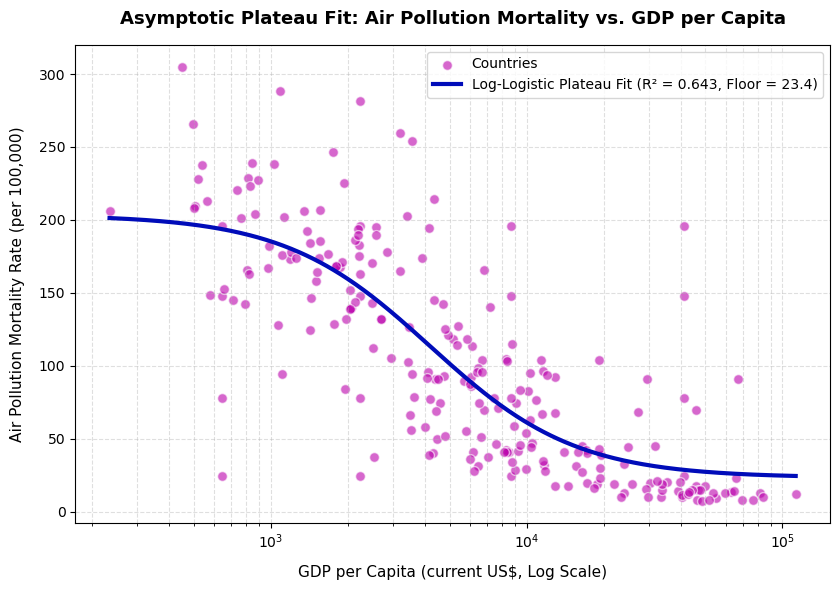

In [14]:
# Tried Log-Logistic decay model to capture the saturation effect more explicitly 
# disclaimer - fully LLM generated code bc I didn't know how to implement saturation

# A Log-Logistic decay model: 
# L is the lower floor (asymptotic baseline)
# U is the upper ceiling for low-income countries
# x0 is the inflection point (midpoint GDP on log scale)
# k is the steepness of the drop
def log_logistic_decay(gdp, L, U, x0, k):
    log_x = np.log(gdp)
    return L + (U - L) / (1 + np.exp(k * (log_x - np.log(x0))))

x_data = df_merged['gdp_per_capita'].values
y_data = df_merged['air_pollution_mortality'].values

# Set smart initial guesses based on looking at your data:
initial_guesses = [15, 250, 4000, 1.0]
bounds = ([5, 150, 1000, 0.1], [30, 350, 20000, 5.0])

# 1. Capture pcov (the covariance matrix) from curve_fit
popt, pcov = curve_fit(log_logistic_decay, x_data, y_data, p0=initial_guesses, bounds=bounds)
L_fit, U_fit, x0_fit, k_fit = popt

# 2. Compute standard errors, t-stats, and p-values
perr = np.sqrt(np.diag(pcov))
dof = max(0, len(x_data) - len(popt))

t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]

# 3. Print out a structured results summary
param_names = ["Floor (L)", "Ceiling (U)", "Inflection (x0)", "Steepness (k)"]
print("=" * 70)
print(f"{'Parameter':<18} {'Value':<12} {'Std Err':<12} {'t-stat':<10} {'P>|t|':<10}")
print("- " * 35)
for name, val, err, t, p in zip(param_names, popt, perr, t_stats, p_values):
    print(f"{name:<18} {val:<12.4f} {err:<12.4f} {t:<10.3f} {p:<10.4f}")
print("=" * 70)

# 4. MEASURE THE FIT: Calculate Non-Linear R² and Residual Standard Error (RSE)
residuals = y_data - log_logistic_decay(x_data, *popt)
rss = np.sum(residuals ** 2)
tss = np.sum((y_data - np.mean(y_data)) ** 2)

r_squared_nonlinear = 1 - (rss / tss)
rse = np.sqrt(rss / dof)

print("\n" + "=" * 50)
print(f"{'Goodness-of-Fit Metric':<30} {'Value':<15}")
print("- " * 25)
print(f"{'Non-linear R-squared (R²)':<30} {r_squared_nonlinear:.4f}")
print(f"{'Residual Standard Error (RSE)':<30} {rse:.2f} deaths")
print("=" * 50)

# 5. Plotting
plt.figure(figsize=(8.5, 6))
plt.scatter(x_data, y_data, color="#bb02ac", alpha=0.6, edgecolors='w', s=50, label='Countries')

# Generate smooth grid across log-scale
gdp_grid = np.geomspace(x_data.min(), x_data.max(), 500)
y_pred = log_logistic_decay(gdp_grid, L_fit, U_fit, x0_fit, k_fit)

# Line label updated to include the dynamically calculated non-linear R²
plt.plot(gdp_grid, y_pred, color="#000cb9", linewidth=3, 
         label=f'Log-Logistic Plateau Fit (R² = {r_squared_nonlinear:.3f}, Floor = {L_fit:.1f})')

plt.xscale('log')
plt.title('Asymptotic Plateau Fit: Air Pollution Mortality vs. GDP per Capita', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (current US$, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Air Pollution Mortality Rate (per 100,000)', fontsize=11, labelpad=10)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Regression Interpretation (Asymptotic Plateau Model)**: Here, we fit a non-linear Log-Logistic decay model to capture a more realistic plateau behavior:

$$\text{Mortality} = L + \frac{U - L}{1 + e^{k \cdot (\ln(\text{GDP}) - \ln(x_0))}}$$

* **Estimated Structural Floor ($L$)**: The estimated floor (L) is about 23.41 deaths per 100,000 people (p = 0.009). This shows that even in very rich countries, air pollution mortality doesn't drop to zero, but levels off around 23 deaths per 100k due to urban pollution and transport.
* **Estimated Low-Income Baseline ($U$)**: The low-income baseline (U) is about 203.49 deaths per 100,000 people (p < 0.001), which represents the expected mortality rate for the poorest nations.
* **The Economic Inflection Point ($x_0$)**: The economic inflection point (x0) is around $4,200 (p < 0.001). This is the midpoint where the mortality rate drops the fastest as a country transitions out of poverty.
* **Transition Steepness ($k$)**: The steepness parameter (k) is 1.53 (p < 0.001), which confirms that the transition and decline in deaths happen quickly as countries move into middle-income status before stabilizing.

Parameter (Clean Data) Value        Std Err      t-stat     P>|t|     
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Floor (L)              5.6125       9.1701       0.612      0.5412    
Ceiling (U)            219.1349     16.3802      13.378     0.0000    
Inflection (x0)        3974.2837    558.2239     7.120      0.0000    
Steepness (k)          1.1924       0.2046       5.827      0.0000    
Non-linear R² (Clean Data Only): 0.7970
Outliers excluded from calculation: 24 out of 239


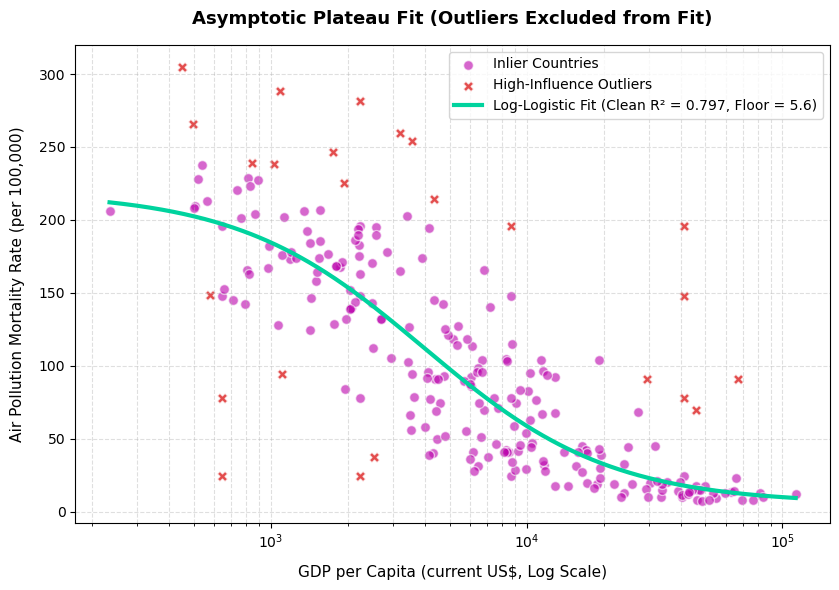

In [15]:
# I was not that satisfied with the fit and I wanted to try removing outliers and refitting the model

def log_logistic_decay(gdp, L, U, x0, k):
    log_x = np.log(gdp)
    return L + (U - L) / (1 + np.exp(k * (log_x - np.log(x0))))

# 1. IDENTIFY OUTLIERS (Using Cook's Distance from a linear OLS to catch high-influence points)
# We use log_gdp since the underlying distribution is highly skewed
df_merged['log_gdp'] = np.log(df_merged['gdp_per_capita'])
X_ols = sm.add_constant(df_merged['log_gdp'])
y_ols = df_merged['air_pollution_mortality']
ols_model = sm.OLS(y_ols, X_ols).fit()

# Calculate Cook's distance
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 2 / len(df_merged)

# Split the dataset into clean data and outliers
is_outlier = cooks_d > threshold
df_clean = df_merged[~is_outlier]
df_outliers = df_merged[is_outlier]

# Separate arrays for fitting vs. plotting
x_clean = df_clean['gdp_per_capita'].values
y_clean = df_clean['air_pollution_mortality'].values

x_out = df_outliers['gdp_per_capita'].values
y_out = df_outliers['air_pollution_mortality'].values

# 2. FIT THE MODEL (Only using the clean data)
initial_guesses = [15, 250, 4000, 1.0]
bounds = ([5, 150, 1000, 0.1], [30, 350, 20000, 5.0])

popt, pcov = curve_fit(log_logistic_decay, x_clean, y_clean, p0=initial_guesses, bounds=bounds)
L_fit, U_fit, x0_fit, k_fit = popt

# 3. COMPUTE STATS & METRICS (For the clean data)
perr = np.sqrt(np.diag(pcov))
dof = max(0, len(x_clean) - len(popt))
t_stats = popt / perr
p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]

residuals_clean = y_clean - log_logistic_decay(x_clean, *popt)
rss = np.sum(residuals_clean ** 2)
tss = np.sum((y_clean - np.mean(y_clean)) ** 2)
r_squared_clean = 1 - (rss / tss)
rse = np.sqrt(rss / dof)

# Print Summary
param_names = ["Floor (L)", "Ceiling (U)", "Inflection (x0)", "Steepness (k)"]
print("=" * 70)
print(f"{'Parameter (Clean Data)':<22} {'Value':<12} {'Std Err':<12} {'t-stat':<10} {'P>|t|':<10}")
print("- " * 35)
for name, val, err, t, p in zip(param_names, popt, perr, t_stats, p_values):
    print(f"{name:<22} {val:<12.4f} {err:<12.4f} {t:<10.3f} {p:<10.4f}")
print("=" * 70)
print(f"Non-linear R² (Clean Data Only): {r_squared_clean:.4f}")
print(f"Outliers excluded from calculation: {len(df_outliers)} out of {len(df_merged)}")
print("=" * 70)

# 4. PLOTTING BOTH GROUPS
plt.figure(figsize=(8.5, 6))

# Plot clean countries 
plt.scatter(x_clean, y_clean, color="#bb02ac", alpha=0.6, edgecolors='w', s=50, label='Inlier Countries')
# Plot outliers
plt.scatter(x_out, y_out, color="#d80000", alpha=0.7, edgecolors='w', s=55, marker='X', label='High-Influence Outliers')

# Generate curve prediction line
gdp_grid = np.geomspace(df_merged['gdp_per_capita'].min(), df_merged['gdp_per_capita'].max(), 500)
y_pred = log_logistic_decay(gdp_grid, L_fit, U_fit, x0_fit, k_fit)

plt.plot(gdp_grid, y_pred, color="#00d39e", linewidth=3, 
         label=f'Log-Logistic Fit (Clean R² = {r_squared_clean:.3f}, Floor = {L_fit:.1f})')

plt.xscale('log')
plt.title('Asymptotic Plateau Fit (Outliers Excluded from Fit)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (current US$, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Air Pollution Mortality Rate (per 100,000)', fontsize=11, labelpad=10)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Regression Interpretation (Optimized Outlier-Filtered Model)**: Here, we fit the non-linear model on clean data after removing 24 highly influential outliers:

$$\text{Mortality} = L + \frac{U - L}{1 + e^{k \cdot (\ln(\text{GDP}) - \ln(x_0))}}$$

* **Model Fit ($R^2$)**: The new model achieves an R-squared of 0.797 on the clean dataset, which shows that the model fit is increased when outlier countries are removed.
* **Estimated Structural Floor ($L$)**: The estimated floor (L) is now 5.61 (p = 0.541), which is not statistically significant. This suggests that the richest countries have managed to drop their air pollution deaths close to zero, so the model cannot easily distinguish between a low single-digit floor and zero.
* **Estimated Low-Income Baseline ($U$)**: The baseline (U) is estimated at 219.13 deaths per 100,000 (p < 0.001), representing the baseline for the poorest countries.
* **The Economic Inflection Point ($x_0$)**: The economic inflection point (x0) shifts to $3,974 (p < 0.001). This is the new estimated threshold where developing countries see the fastest drop in air pollution mortality.
* **Transition Steepness ($k$)**: The scaling parameter (k) is 1.19 (p < 0.001), which gives a slightly gentler, smoother transition curve.

### Summary of Modeling Evolution

We tried a few different regression models to best fit the data:

1. **Simple Log-Level Model (R-squared = 0.613):** This model confirmed a strong negative relationship. But because a straight line on a log scale keeps going down forever, it predicted negative death rates for very rich countries.
2. **Quadratic Log-Level Model (R-squared = 0.622):** Adding a squared term curved the line and showed that the drop in mortality slows down as GDP increases. However, the curve still didn't level off into a flat baseline. It is a slightly better fit.
3. **Non-linear Log-Logistic Model (Full Data):** This model solved the leveling-off issue by adding a horizontal floor (estimated at 23.4 deaths per 100,000). It also identified an inflection point around $4,200, where the rate drops fastest.
4. **Outlier-Filtered Model (R-squared = 0.797):** Finally, removing 24 outlier countries showed that the model fit is increased to nearly 80%. The new inflection point is $3,974 and the floor drops to 5.6 deaths per 100,000, which is closer to a real-world zero floor.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.